<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/0515_%EC%84%B8%EC%85%98_%EC%8B%9C%EA%B3%84%EC%97%B4_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **OB 시계열 연습문제**


AAPL(Apple Inc.)의 주가 데이터를 이용하여, 과거 60일의 종가 데이터를 입력으로 받아 다음 날의 주가를 예측하는 LSTM 모델을 구현하고 예측 결과를 시각화해봅시다.🚀

### 0. 필요 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# device 설정: 가능하면 GPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 1. 데이터 다운로드 및 전처리

1-a. yfinance 라이브러리를 사용해 AAPL(Apple Inc.)의 주가 데이터를 2010년 1월 1일부터 2023년 1월 1일까지 다운로드하세요. 다운로드한 데이터에서 'Close' 컬럼만 선택하고, 결측치를 제거하세요.

힌트: yf.download(ticker, start, end) 함수를 사용합니다.


In [2]:
# 데이터 로드
# yfinance를 사용하여 AAPL 데이터를 가져옵니다.
df = yf.download('AAPL', start='2010-01-01', end='2023-01-01')

# Close 칼럼만 선택
# 예측에 사용할 종가(Close) 데이터만 추출합니다.
df = df[['Close']]

# 결측치 제거
# 데이터 중 비어있는 값이 있다면 제거하여 모델의 오류를 방지합니다.
df = df.dropna()

# 데이터 확인
print(df.head())

/tmp/ipykernel_1645/4142195612.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2010-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

Price          Close
Ticker          AAPL
Date                
2010-01-04  6.406480
2010-01-05  6.417557
2010-01-06  6.315476
2010-01-07  6.303802
2010-01-08  6.345712


1-b. MinMaxScaler를 이용해 데이터를 0~1 범위로 정규화하세요.

In [3]:
# 데이터 정규화
scaler = MinMaxScaler(feature_range=(0, 1))

# fit_transform은 데이터를 학습함과 동시에 변환합니다.
# 반드시 2차원 배열 형태여야 하므로 values.reshape(-1, 1)을 사용합니다.
scaled_data = scaler.fit_transform(df.values.reshape(-1, 1))

# 정규화된 데이터 확인
print(scaled_data[:5])

[[0.00381776]
 [0.00388208]
 [0.00328925]
 [0.00322145]
 [0.00346485]]


### 2. 시퀀스 데이터 생성

정규화된 데이터를 바탕으로, 슬라이딩 윈도우 기법을 사용하여 지난 60일의 데이터를 입력 시퀀스로, 61번째 날의 데이터를 타깃으로 하는 시퀀스 데이터셋을 생성하세요.

힌트: for 루프를 활용해 인덱스를 이동하면서 각 시퀀스를 구성합니다. 시퀀스 데이터 생성 함수를 정의해 사용할 수 있습니다.

In [4]:
# 2. 시퀀스 데이터 생성 함수 (예: 지난 60일을 보고 다음 날 예측)

def create_sequences(data, window_size):
    X = []
    y = []

    # 전체 데이터 길이에서 window_size만큼 뺀 만큼 루프를 돕니다.
    # 그래야 마지막 시퀀스(60일) 뒤에 예측할 타깃(1일) 데이터가 존재할 수 있습니다.
    for i in range(len(data) - window_size):
        # i부터 i + window_size 전까지의 데이터를 입력 시퀀스(X)에 추가
        X.append(data[i : i + window_size])
        # i + window_size 위치의 데이터를 타깃(y)에 추가
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

# 윈도우 사이즈 설정 (과제 조건에 따라 60일로 설정)
window_size = 60

# 앞서 정규화한 scaled_data를 사용하여 시퀀스 생성
X, y = create_sequences(scaled_data, window_size)

# 생성된 데이터의 형태(Shape) 확인
print(f"학습용 데이터(X)의 형태: {X.shape}")  # (샘플 수, 60, 1)
print(f"타깃 데이터(y)의 형태: {y.shape}")    # (샘플 수, 1)

학습용 데이터(X)의 형태: (3212, 60, 1)
타깃 데이터(y)의 형태: (3212, 1)


### 3. 데이터셋 분할 및 Pytorch 텐서로 변환

3-a. 생성한 시퀀스 데이터를 학습용(80%)과 테스트용(20%)으로 분리하세요.

In [5]:
# 3-a. 데이터셋을 학습용과 테스트용으로 분리 (80% 학습, 20% 테스트)

# 분리 지점 계산 (전체 데이터 개수의 80% 지점 인덱스)
train_size = int(len(X) * 0.8)

# 시간 순서를 유지하며 슬라이싱하여 분리
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 결과 확인
print(f"Total samples: {len(X)}")
print(f"Train samples: {len(X_train)} (80%)")
print(f"Test samples: {len(X_test)} (20%)")

Total samples: 3212
Train samples: 2569 (80%)
Test samples: 643 (20%)


3-b. 분리한 데이터를 PyTorch 텐서(torch.FloatTensor)로 변환하고, 타깃 데이터의 차원도 (batch_size, 1)로 맞추세요.

In [6]:
# # 3. PyTorch 텐서로 변환
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)

In [7]:
# # 타깃 텐서의 차원 변경: (batch_size, 1)
# 이미 (샘플 수, 1) 형태라면 그대로 두어도 되지만,
# 명시적으로 차원을 확인하고 맞추기 위해 view나 reshape를 사용합니다.
y_train_t = y_train_t.view(-1, 1)
y_test_t = y_test_t.view(-1, 1)

### 4. LSTM 모델 정의

PyTorch를 이용해 LSTM 모델을 구현하세요.
모델은 하나 이상의 LSTM 레이어와 최종 출력을 위한 Fully Connected(FC) 레이어로 구성되어야 합니다.
순전파(forward) 함수에서 초기 hidden state와 cell state를 올바르게 초기화하세요.

힌트: 교재 p.414 내용 참고

In [8]:
# 4. LSTM 모델 정의

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM 레이어: batch_first=True는 입력 데이터 형식을 [batch, seq, feature]로 받겠다는 의미입니다.
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        # 최종 출력을 위한 Fully Connected 레이어
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # 초기 hidden state와 cell state를 0으로 초기화
        # (num_layers, batch_size, hidden_dim)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)

        # LSTM 통과
        # out: 각 시점의 hidden state들, (hn, cn): 마지막 시점의 상태
        out, (hn, cn) = self.lstm(x, (h0, c0))

        # 마지막 시점(last time step)의 hidden state만 사용하여 다음 날 주가 예측
        out = self.fc(out[:, -1, :])
        return out

# 하이퍼파라미터 설정 및 모델 객체 생성
input_dim = 1      # 입력 피처 (종가 1개)
hidden_dim = 64    # 은닉 상태의 크기
output_dim = 1     # 출력 피처 (다음 날 종가 1개)
num_layers = 2     # LSTM 레이어 층 수

model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)

print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### 5. 모델학습

5-a. 모델학습에 필요한 변수 값들(criterion, optimizer, num_epochs 등)을 정의하세요. (시간 상 epoch수는 30으로 하는 것을 추천합니다.)

In [9]:
# 손실함수와 옵티마이저 정의
num_epochs = 30
learning_rate = 0.01

# 회귀 분석에 적합한 MSE 손실 함수 사용
criterion = nn.MSELoss()

# 가중치를 효율적으로 업데이트하는 Adam 옵티마이저 사용
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

5-b. 정의한 LSTM 모델을 사용해 학습을 진행하세요.학습 과정에서 MSELoss를 손실함수로, Adam Optimizer를 최적화 도구로 사용하세요.

In [10]:
# 모델 학습
model.train() # 학습 모드 전환

for epoch in range(num_epochs):
    # 데이터를 설정된 장치(CPU/GPU)로 보냅니다
    inputs = X_train_t.to(device)
    targets = y_train_t.to(device)

    # Forward pass: 모델에 입력을 넣어 예측값 계산
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward and optimize: 기울기 초기화 -> 역전파 -> 가중치 업데이트
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 5회마다 학습 로그 출력
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.6f}')

print("모델 학습이 완료되었습니다.")

Epoch [5/30], Loss: 0.014792
Epoch [10/30], Loss: 0.008862
Epoch [15/30], Loss: 0.008490
Epoch [20/30], Loss: 0.008254
Epoch [25/30], Loss: 0.006754
Epoch [30/30], Loss: 0.006969
모델 학습이 완료되었습니다.


### 6. 예측 결과 시각화

테스트 데이터를 활용하여 모델의 예측을 수행한 후, 예측 결과와 실제 주가를 비교하는 그래프를 작성하세요.
예측 결과와 실제 값은 정규화된 값이므로, scaler.inverse_transform을 사용해 원래 주가 값으로 복원해야 합니다.

힌트: 모델 예측 시 GPU를 사용했다면 .cpu().detach().numpy()를 통해 NumPy 배열로 변환하세요.


In [11]:
# 테스트 데이터에 대한 예측
model.eval() # 평가 모드로 전환 (Dropout이나 Batchnorm이 있다면 필수)
with torch.no_grad(): # 예측 시에는 기울기를 계산할 필요가 없음
    # 테스트 데이터를 모델에 입력
    test_predict = model(X_test_t.to(device))

# 텐서를 numpy 배열로 변환 (GPU 사용 시 .cpu() 필요)
# detach()는 연산 그래프에서 분리하고, numpy()는 넘파이 배열로 바꿉니다.
test_predict_np = test_predict.cpu().detach().numpy()
y_test_np = y_test_t.cpu().detach().numpy()

In [12]:
# 정규화 복원: 실제 주가 값으로 변환
# scaler.inverse_transform을 사용하여 0~1 사이의 값을 원래 가격으로 되돌립니다.
test_predict_inverse = scaler.inverse_transform(test_predict_np)
y_test_inverse = scaler.inverse_transform(y_test_np)

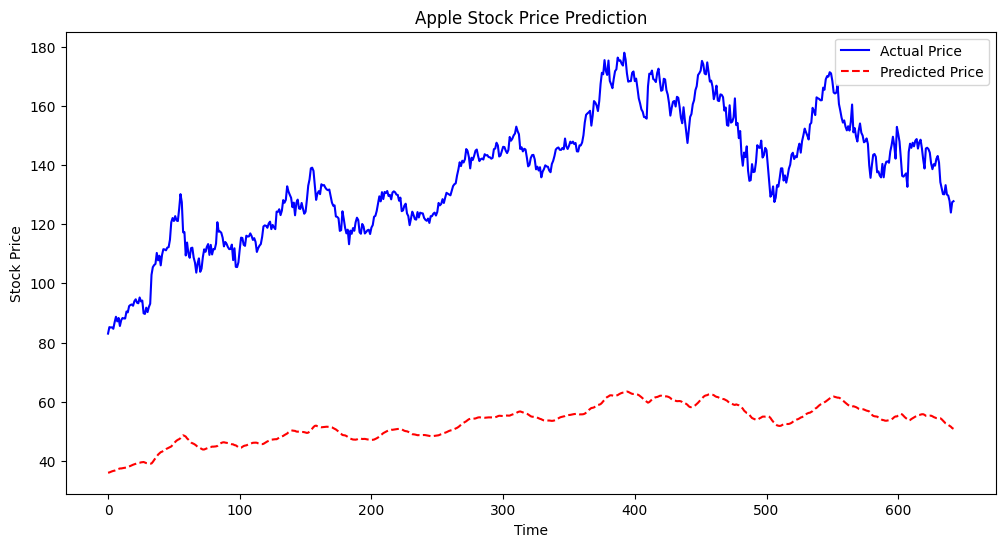

In [13]:
# 결과 시각화
plt.figure(figsize=(12, 6))

# 실제 주가 그래프 (Actual)
plt.plot(y_test_inverse, label='Actual Price', color='blue')

# 모델의 예측 주가 그래프 (Predicted)
plt.plot(test_predict_inverse, label='Predicted Price', color='red', linestyle='--')

plt.title('Apple Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()